In [1]:
import pandas as pd
import numpy as np
import mobileDataToolkit.preprocessing_v2 as preprocessing
import utils.helper_func as helper_func
import geopandas as gpd

C:\Users\stlp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Can't load requested DLL: C:\Program Files\GDAL\gdalplugins\gdal_FITS.dll
127: The specified procedure could not be found.

Can't load requested DLL: C:\Program Files\GDAL\gdalplugins\gdal_FITS.dll
127: The specified procedure could not be found.

Can't load requested DLL: C:\Program Files\GDAL\gdalplugins\gdal_HDF4.dll
127: The specified procedure could not be found.

Can't load requested DLL: C:\Program Files\GDAL\gdalplugins\gdal_HDF4.dll
127: The specified procedure could not be found.

Can't load requested DLL: C:\Program Files\GDAL\gdalplugins\gdal_HDF5.dll
127: The specified procedure could not be found.

Can't load requested DLL: C:\Program 

In [2]:
# Load sampled data
df = pd.read_csv('C:\\Users\\stlp\\OneDrive - UW\\GPR\\Data\\seattle_2000_all_obs_preprocessed_sampled.csv')

In [3]:
df.head()

,UID,orig_lat,orig_long,orig_unc,datetime,unix_min,DoW,Year,Month,Day,Week,Hour,WoM,SaM,Holiday
0,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.555557,-122.050186,65.0,2019-12-31 06:31:49,0,1,2019,12,31,1,6,5,23509,0
1,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.551100,-122.052466,65.0,2019-12-31 06:53:18,21,1,2019,12,31,1,6,5,24798,0
2,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.551393,-122.053351,65.0,2019-12-31 07:08:22,36,1,2019,12,31,1,7,5,25702,0
3,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.551065,-122.052334,65.0,2019-12-31 07:18:00,46,1,2019,12,31,1,7,5,26280,0
4,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.555557,-122.050186,65.0,2019-12-31 07:19:26,47,1,2019,12,31,1,7,5,26366,0


In [4]:
mod = preprocessing.dp_MultiTrip(df)
mod.chooseUser(df.UID.unique()[0])

In [5]:
# Add datetime column without time
mod.data['date'] = pd.to_datetime(mod.data['datetime']).dt.date

# Check which days in April have the most observations
mod.data[pd.to_datetime(mod.data['datetime']).dt.month == 4].groupby('date').count().sort_values('datetime', ascending=False)['UID'].head()

C:\Users\stlp\AppData\Local\Temp\ipykernel_10836\4107106159.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod.data['date'] = pd.to_datetime(mod.data['datetime']).dt.date


date
2020-04-30    297
2020-04-22    284
2020-04-03    247
2020-04-08    229
2020-04-29    213
Name: UID, dtype: int64

In [6]:
# Choose the day with the most observations as our test day
test_day = mod.data[pd.to_datetime(mod.data['datetime']).dt.month == 4].groupby('date').count().sort_values('datetime', ascending=False).index[0]

# Check the hourly sampling distribution for our test day
mod.data[mod.data['date'] == test_day].groupby(pd.to_datetime(mod.data['datetime']).dt.hour).count()['UID'].sort_values(ascending=False)

datetime
12    88
2     59
3     32
0     32
13    20
1     18
5      5
4      4
9      4
17     3
22     3
7      3
20     3
18     3
16     3
21     2
19     2
23     2
15     2
11     2
10     2
8      2
6      2
14     1
Name: UID, dtype: int64

In [7]:
mod.data[mod.data['date'] == test_day].groupby(pd.to_datetime(mod.data['datetime']).dt.hour).count()['UID'].sort_values(ascending=False).index[:2]

Int64Index([12, 2], dtype='int64', name='datetime')

In [8]:
# Choose three hours with the most observations as our test hours
test_hours = mod.data[mod.data['date'] == test_day].groupby(pd.to_datetime(mod.data['datetime']).dt.hour).count()['UID'].sort_values(ascending=False).index[:3]

# Segment dataset accordingly
mod.subsetByTime(starttime='{} {}'.format(str(test_day), str(test_hours[0]) + ':00:00'), endtime='{} {}'.format(str(test_day), str(test_hours[-1]) + ':00:00'))

,index,UID,orig_lat,orig_long,orig_unc,datetime,unix_min,DoW,Year,Month,Day,Week,Hour,WoM,SaM,Holiday,date
0,34417,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.555557,-122.050186,65.0,2020-04-30 12:09:51,174518,3,2020,4,30,18,12,5,43791,0,2020-04-30
1,34418,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.555557,-122.050186,5.0,2020-04-30 12:10:10,174518,3,2020,4,30,18,12,5,43810,0,2020-04-30
2,34419,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.550912,-122.054413,10.0,2020-04-30 12:11:09,174519,3,2020,4,30,18,12,5,43869,0,2020-04-30
3,34420,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.551793,-122.058559,10.0,2020-04-30 12:11:54,174520,3,2020,4,30,18,12,5,43914,0,2020-04-30
4,34421,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.550927,-122.066730,10.0,2020-04-30 12:12:40,174520,3,2020,4,30,18,12,5,43960,0,2020-04-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,34544,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.446320,-122.204887,65.0,2020-04-30 22:15:42,175123,3,2020,4,30,18,22,5,80142,0,2020-04-30
128,34545,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.446320,-122.204887,65.0,2020-04-30 22:36:44,175144,3,2020,4,30,18,22,5,81404,0,2020-04-30
129,34546,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.446320,-122.204887,65.0,2020-04-30 22:55:53,175164,3,2020,4,30,18,22,5,82553,0,2020-04-30
130,34547,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.446320,-122.204887,65.0,2020-04-30 23:16:24,175184,3,2020,4,30,18,23,5,83784,0,2020-04-30


In [9]:
import torch
import gpytorch
from gpytorch.kernels import RQKernel as RQ, RBFKernel as SE, \
PeriodicKernel as PER, ScaleKernel, LinearKernel as LIN, MaternKernel as MAT, \
SpectralMixtureKernel as SMK, PiecewisePolynomialKernel as PPK, CylindricalKernel as CYL
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error
from gpytorch.constraints import Interval
import time

import mobileDataToolkit.methods as methods

In [10]:
mod.data.columns

Index(['index', 'UID', 'orig_lat', 'orig_long', 'orig_unc', 'datetime',
       'unix_min', 'DoW', 'Year', 'Month', 'Day', 'Week', 'Hour', 'WoM', 'SaM',
       'Holiday', 'date'],
      dtype='object')

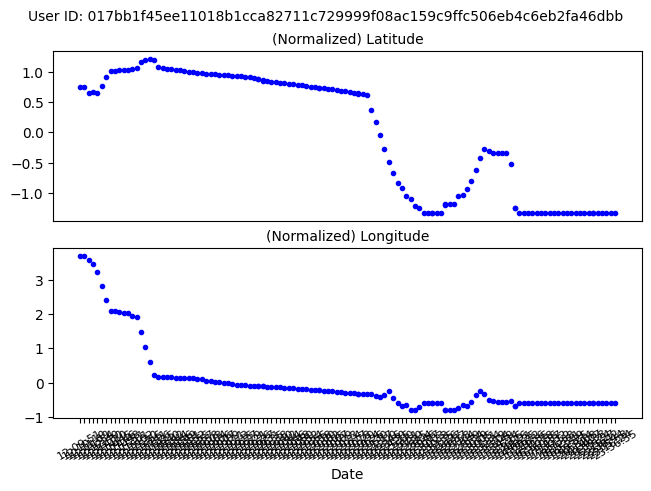

In [11]:
mod.add_NormCoords()

methods.mobVisualize(mod.data)

In [12]:
# Move columns
cols = list(mod.data.columns)
cols = cols[:6] + cols[7:14] + cols[16:19] + cols[6:7] + cols[14:16]
mod.data = mod.data[cols]
mod.data.head()

,index,UID,orig_lat,orig_long,orig_unc,datetime,DoW,Year,Month,Day,Week,Hour,WoM,date,norm_lat,norm_long,unix_min,SaM,Holiday
0,34417,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.555557,-122.050186,65.0,2020-04-30 12:09:51,3,2020,4,30,18,12,5,2020-04-30,0.74261373,3.6812813,174518,43791,0
1,34418,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.555557,-122.050186,5.0,2020-04-30 12:10:10,3,2020,4,30,18,12,5,2020-04-30,0.74261373,3.6812813,174518,43810,0
2,34419,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.550912,-122.054413,10.0,2020-04-30 12:11:09,3,2020,4,30,18,12,5,2020-04-30,0.65432346,3.5646317,174519,43869,0
3,34420,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.551793,-122.058559,10.0,2020-04-30 12:11:54,3,2020,4,30,18,12,5,2020-04-30,0.67106825,3.4502132,174520,43914,0
4,34421,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.550927,-122.066730,10.0,2020-04-30 12:12:40,3,2020,4,30,18,12,5,2020-04-30,0.6546086,3.2247157,174520,43960,0


## Induce gaps
* First, let's check current temporal occupancy with a 15-min bin length

In [13]:
# Check current temporal occupancy
print("Current temporal occupancy: ", mod.tempOcp(bin_len=15, test=False))

Current temporal occupancy:  0.6086956521739131


Ok, we want to reduce this to our target level. The points we remove will be our testing set.

In [14]:
import mobileDataToolkit.analysis as analysis

# Define target temporal occupancy
target_temp_ocp = 0.4

# Simulate gaps in the user's data to match the target level
gapped_user_data, train_index = analysis.simulate_gaps(mod.data, target_temp_ocp, bin_len=15)


New temporal occupancy is 0.391304347826087.


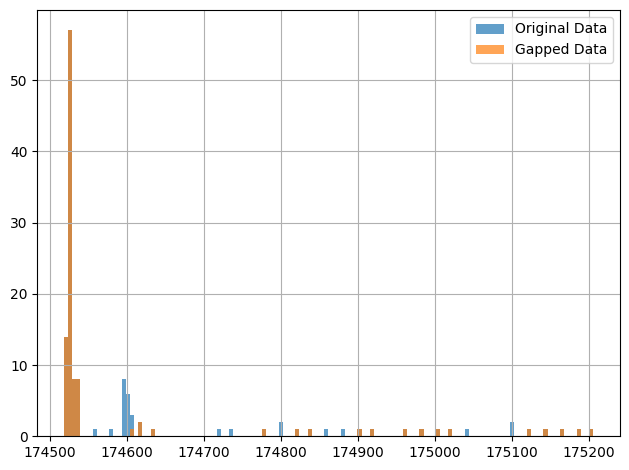

In [15]:
# Visualize the gapped data
mod.data.unix_min.hist(bins=128, label='Original Data', alpha=0.7)
gapped_user_data.unix_min.hist(bins=128, label='Gapped Data', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.show()

In [16]:
train = mod.data.iloc[train_index].copy()
test = mod.data.drop(train_index).copy()

print(len(train))
len(test)

105


27

### Stack the local training set with the longitudinal training data


In [17]:
# Stack local training set with longitudinal training data
longitudinal = preprocessing.dp_MultiTrip(df)
longitudinal.chooseUser(df.UID.unique()[0])

# Add datetime column without time
longitudinal.data['date'] = pd.to_datetime(longitudinal.data['datetime']).dt.date

# Choose every day except the test day as our longitudinal training data
longitudinal.data = longitudinal.data[longitudinal.data['date'] != test_day]

C:\Users\stlp\AppData\Local\Temp\ipykernel_10836\2297175574.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  longitudinal.data['date'] = pd.to_datetime(longitudinal.data['datetime']).dt.date


In [18]:
# Stack local training set with longitudinal training data
train = pd.concat([train, longitudinal.data])

In [19]:
%cd ..

c:\Users\stlp\GPSImpute


In [20]:
import mobileDataToolkit.methods as methods

In [21]:
helper_func.addDist(train, type=helper_func.haversine_np)
helper_func.addVel(train)
home_lat, home_lon = methods.homeLocv2(train)

Adding distance column to dataframe...
Adding velocity column to dataframe...


### Scikit-Mobility Processing
* Filter by max velocity
* Compress points by spatial heuristic
* Detect stay locations

In [22]:
import skmob.preprocessing.detection

In [23]:
%%time
tdf = skmob.TrajDataFrame(train, latitude='orig_lat', longitude='orig_long', datetime='datetime')
f_tdf = skmob.preprocessing.filtering.filter(tdf, max_speed_kmh=400, include_loops=True)
fc_tdf = skmob.preprocessing.compression.compress(f_tdf, spatial_radius_km=0.1) # vary the spatial radius to see how prediction changes
fcs_tdf = skmob.preprocessing.detection.stay_locations(fc_tdf)

CPU times: total: 4.19 s
Wall time: 4.46 s


In [24]:
n_deleted_points = len(tdf) - len(f_tdf) # number of deleted points during filtering
print(n_deleted_points)

1726


In [25]:
n_deleted_points = len(f_tdf) - len(fc_tdf) # number of deleted points during compression
n_deleted_points / len(train)

0.5505864157752288

In [26]:
# m = fcs_tdf.plot_trajectory(max_users=1, start_end_markers=False)
#fcs_tdf.plot_stops(map_f=m)

In [27]:
import skmob.preprocessing.clustering

In [28]:
fcsc_tdf = skmob.preprocessing.clustering.cluster(fcs_tdf, cluster_radius_km=0.2, min_samples=1)
# m2 = fcsc_tdf.plot_trajectory(max_users=1, start_end_markers=False)
#fcsc_tdf.plot_stops(map_f=m2)

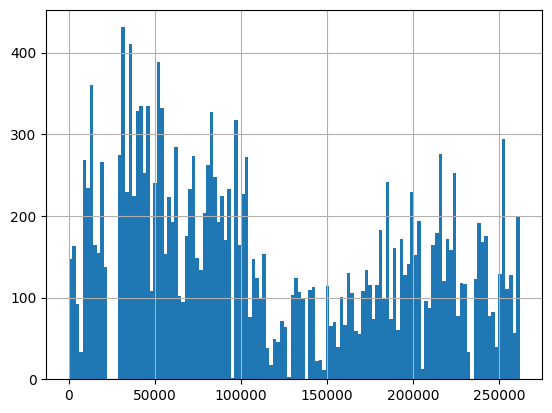

In [29]:
# This is the temporal distribution of the data we will predict with now looks like
fc_tdf.unix_min.hist(bins=128)
plt.show()

In [30]:
# Filter out inaccurate data
print(len(fc_tdf))
fc_tdf = fc_tdf[fc_tdf['orig_unc'] < 100]
print(len(fc_tdf))

# Sanity check to remove any test data that may have been included in the training set
test = test[~test['datetime'].isin(fc_tdf['datetime'])]

19196
19123


In [31]:
# Make training set's datetime column a datetime object
train['datetime'] = pd.to_datetime(train['datetime'])

# Filter out data that is not in fc_tdf from the training set
train_sparse = train[train['datetime'].isin(fc_tdf['datetime'])]

## We're ready to build a model

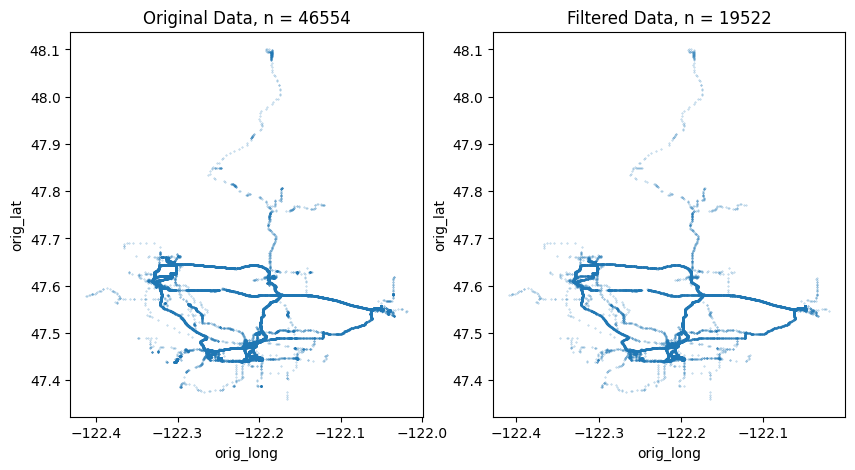

In [32]:
f, axs = plt.subplots(1, 2, figsize=(10, 5))
train.plot(x='orig_long', y='orig_lat', kind='scatter', alpha=0.5, s=0.1, ax=axs[0])
axs[0].set_title('Original Data, n = {}'.format(len(train)))
train_sparse.plot(x='orig_long', y='orig_lat', kind='scatter', alpha=0.5, s=0.1, ax=axs[1])
axs[1].set_title('Filtered Data, n = {}'.format(len(train_sparse)))
plt.show()

In [33]:
# Put training dataframe into a geodataframe
train_gdf = gpd.GeoDataFrame(train, geometry=gpd.points_from_xy(train.orig_long, train.orig_lat))

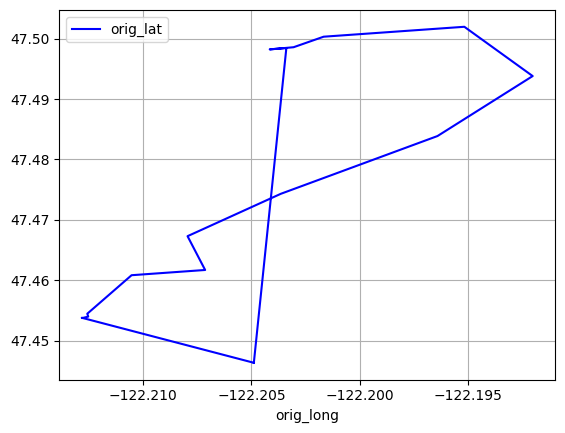

In [34]:
test.plot(x='orig_long', y='orig_lat', alpha=1, color='blue')
plt.grid()
plt.show()

### Train/Test Split

In [46]:
# Get start and end times of the gapped user data
start_time = test['datetime'].min()
end_time= test['datetime'].max()

In [47]:
# Concatenate the sparse training and test data
train_test = pd.concat([train_sparse, test])
# Convert datetime column to datetime object
train_test['datetime'] = pd.to_datetime(train_test['datetime'])
# Sort by datetime
train_test = train_test.sort_values(by='datetime')

In [48]:
train_test_class = preprocessing.dp_MultiTrip(train_test)
train_test_class.chooseUser(train_test.UID.unique()[0])

# Run Multi_Trip_Preprocess method to get the training data in the correct format
train_test_class.Multi_Trip_Preprocess()

c:\users\stlp\gpsimpute\mobileDataToolkit\preprocessing_v2.py:117: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated. Please use Series.dt.isocalendar().week instead.
  self.data['Week'] = self.data['datetime'].dt.week


In [49]:
# IMPORTANT: these lines find the index at which the temporal input dimensions are located within the full dataframe
inputstart = "unix_min"
inputend = "week_" + str(train_test_class.weeks_col[-1])

time_start_loc = train_test_class.data.columns.get_loc(inputstart)
time_end_loc = train_test_class.data.columns.get_loc(inputend) + 1

test_start_date = start_time
test_end_date = end_time

X_train = torch.tensor(np.asarray(train_test_class.data.iloc[:, time_start_loc:time_end_loc][
    (train_test_class.data['datetime'] < test_start_date) | (train_test_class.data['datetime'] > test_end_date)
    ]).astype(float))
X_test = torch.tensor(np.asarray(train_test_class.data.iloc[:, time_start_loc:time_end_loc][
    (train_test_class.data['datetime'] >= test_start_date) & (train_test_class.data['datetime'] <= test_end_date)
    ]).astype(float))
y_train_lat = torch.tensor(np.asarray(train_test_class.data['orig_lat'][
    (train_test_class.data['datetime'] < test_start_date) | (train_test_class.data['datetime'] > test_end_date)
    ]).astype(float))
y_test_lat = torch.tensor(np.asarray(train_test_class.data['orig_lat'][
    (train_test_class.data['datetime'] >= test_start_date) & (train_test_class.data['datetime'] <= test_end_date)
    ]).astype(float))
y_train_long = torch.tensor(np.asarray(train_test_class.data['orig_long'][
    (train_test_class.data['datetime'] < test_start_date) | (train_test_class.data['datetime'] > test_end_date)
    ]).astype(float))
y_test_long = torch.tensor(np.asarray(train_test_class.data['orig_long'][
    (train_test_class.data['datetime'] >= test_start_date) & (train_test_class.data['datetime'] <= test_end_date)
    ]).astype(float))
glob_t_train = torch.tensor(np.asarray(train_test_class.data['unix_min'][
    (train_test_class.data['datetime'] < test_start_date) | (train_test_class.data['datetime'] > test_end_date)
    ]).astype(float))
glob_t_test = torch.tensor(np.asarray(train_test_class.data['unix_min'][
    (train_test_class.data['datetime'] >= test_start_date) & (train_test_class.data['datetime'] <= test_end_date)
    ]).astype(float))
date_train = train_test_class.data['datetime'][
    (train_test_class.data['datetime'] < test_start_date) | (train_test_class.data['datetime'] > test_end_date)
    ]
date_test = train_test_class.data['datetime'][
    (train_test_class.data['datetime'] >= test_start_date) & (train_test_class.data['datetime'] <= test_end_date)
    ]
prec_train = torch.tensor(np.asarray(train_test_class.data['orig_unc'][
    (train_test_class.data['datetime'] < test_start_date) | (train_test_class.data['datetime'] > test_end_date)
    ]).astype(float))
prec_test = torch.tensor(np.asarray(train_test_class.data['orig_unc'][
    (train_test_class.data['datetime'] >= test_start_date) & (train_test_class.data['datetime'] > test_end_date)
    ]).astype(float))

# Stack the lat and long together
y_train = torch.stack(
            [
                y_train_lat, y_train_long 
                ], -1)
y_test = torch.stack(
            [
                y_test_lat, y_test_long
                ], -1)

# Create a dataframe of the training and test data
train_df = pd.DataFrame({'unix_min': glob_t_train,
                            'date': date_train,
                            'lat': [y_train_lat[i].item() for i in range(0, len(y_train_lat))],
                            'long': [y_train_long[i].item() for i in range(0, len(y_train_long))]},
                            columns = ['unix_min', 'date', 'lat', 'long'])
train_df = train_df.sort_values(by=['unix_min'])

test_df = pd.DataFrame({'unix_min': glob_t_test,
                    'date': date_test,
                    'lat': [y_test_lat[i].item() for i in range(0, len(y_test_lat))],
                    'long': [y_test_long[i].item() for i in range(0, len(y_test_long))]},
                    columns = ['unix_min', 'date', 'lat', 'long'])
test_df = test_df.sort_values(by=['unix_min'])

#### Normalize Data

In [50]:
scaler1 = MinMaxScaler()
scaler2 = MinMaxScaler()
scaler3 = MinMaxScaler()

unix_train = torch.tensor(scaler1.fit_transform(X_train[:,0].reshape(-1,1))).float()
secs_train = torch.tensor(scaler2.fit_transform(X_train[:,1].reshape(-1,1))).float()
unix_test = torch.tensor(scaler1.transform(X_test[:,0].reshape(-1,1))).float()
secs_test = torch.tensor(scaler2.transform(X_test[:,1].reshape(-1,1))).float()

X_train = torch.cat([unix_train, secs_train, X_train[:, 2::]], -1).float()
X_test = torch.cat([unix_test, secs_test, X_test[:, 2::]], -1).float()

y_train = torch.tensor(scaler3.fit_transform(y_train)).float()
y_test = torch.tensor(scaler3.transform(y_test)).float()

n_dims = X_train.shape[1]

In [51]:
import utils.GP as GP

model = GP.MTGPRegressor(X_train, y_train, ScaleKernel(RQ(ard_num_dims=n_dims)) * ScaleKernel(PER(active_dims=torch.tensor([0]))))

### Initialize RQ kernel lengthscale to 15 minutes (for unix_min and SaM)

In [52]:
scaled_lengthscale_unix_min = scaler1.transform(torch.tensor(15).reshape(-1,1)).item()
scaled_lengthscale_secs = scaler2.transform(torch.tensor(900).reshape(-1,1)).item()
scaled_period = scaler1.transform(torch.tensor(10080).reshape(-1,1))
initializations = np.ones(n_dims - 2)
initializations = np.insert(initializations, 0, [scaled_lengthscale_unix_min, scaled_lengthscale_secs])

model.covar_module.data_covar_module.kernels[0].base_kernel.lengthscale = initializations
model.covar_module.data_covar_module.kernels[1].base_kernel.period_length = scaled_period

In [53]:
import tqdm

model.train()
model.likelihood.train()
training_parameters = model.parameters()
lr=0.3
optimizer = torch.optim.Adam(training_parameters, lr=lr)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(model.likelihood, model)
loss_threshold = 0.00001
n_epochs = 200
verbose=True

counter = 0
ls = list()
with tqdm.trange(n_epochs, disable=not verbose) as bar:
    for i in bar:

        optimizer.zero_grad()
        
        output = model(X_train)
        loss = -mll(output, y_train)
        loss.backward()
        ls.append(loss.item())
        optimizer.step()
        if (i > 0):
            if abs(ls[counter - 1] - ls[i]) < loss_threshold:
                break
        counter = counter + 1
                    
        # display progress bar
        postfix = dict(Loss=f"{loss.item():.3f}",
                        noise=f"{model.likelihood.noise.item():.3}")

  0%|          | 0/200 [00:00<?, ?it/s]


RuntimeError: You must train on the training inputs!